In [4]:
import numpy as np
import os

npz_path = "/gpfs/home/machlm03/Segmentation/OAI_demo/MedSam2_Finetune_OAI_Inference_bbx/9217260_00m_RIGHT_SAG_3D_DESS_WE.npz"  # adjust if needed

data = np.load(npz_path)
for key in data.files:
    print(f"{key}: shape = {data[key].shape}")

imgs: shape = (160, 384, 384)
pre: shape = (160, 384, 384)
gts: shape = (160, 384, 384)


In [1]:
import pandas as pd
import os

# Directory containing the CSV files
base_dir = "/gpfs/home/machlm03/Segmentation/MedSAM2/oai_utils/results"

# Initialize an empty list to collect DataFrames
dfs = []

# Loop over folds (adjust range as needed)
for i in range(10):  # for fold0.csv to fold9.csv
    file_path = os.path.join(base_dir, f"fold{i}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df = df.tail(8)[["case_name", "mean_dice", "mean_iou", "mean_hd"]]
        df["fold"] = str(i)
        df.reset_index(drop=True, inplace=True)
        dfs.append(df)
    else:
        print(f"File not found: {file_path}")

# Read MedSAM inference results
medsam_df = pd.read_csv(os.path.join(base_dir, "MedSAM2_Inference.csv"))
medsam_df = medsam_df.tail(8)[["case_name", "mean_dice", "mean_iou", "mean_hd"]]
medsam_df["fold"] = "MedSAM"
medsam_df.reset_index(drop=True, inplace=True)

# Combine all into one DataFrame
final_df = pd.concat(dfs + [medsam_df], ignore_index=True)


final_df = final_df[["fold", "case_name", "mean_dice", "mean_iou", "mean_hd"]]


In [2]:
final_df['fold'].unique()


array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'MedSAM'],
      dtype=object)

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named final_df and has:
# 'case_name', 'mean_dice', 'mean_iou', 'mean_hd', 'fold'

# Define the order of structures for consistent display
structure_order = [
    "Femur", "Tibia", "Patella", "Femoral Cartilage",
    "Tibial Cartilage", "Patellar Cartilage", "Meniscus", "Overall"
]

# Create pivot tables for each metric
dice_data = final_df.pivot(index="case_name", columns="fold", values="mean_dice").loc[structure_order]
iou_data = final_df.pivot(index="case_name", columns="fold", values="mean_iou").loc[structure_order]
hd_data = final_df.pivot(index="case_name", columns="fold", values="mean_hd").loc[structure_order]

# Set up subplots
fig, axes = plt.subplots(1, 3, figsize=(30, 10))


# Plot Dice heatmap
sns.heatmap(dice_data, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Dice Score'})
axes[0].set_title("Dice Coefficient Across Folds")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("")

# Plot IoU heatmap
sns.heatmap(iou_data, annot=True, fmt=".3f", cmap="YlOrBr", ax=axes[1], cbar_kws={'label': 'IoU Score'})
axes[1].set_title("IoU Across Folds")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("")
axes[1].set_yticklabels([])

# Plot Hausdorff Distance heatmap
sns.heatmap(hd_data, annot=True, annot_kws={"size": 12},fmt=".2f", cmap="coolwarm", ax=axes[2], cbar_kws={'label': 'Hausdorff Distance'})
axes[2].set_title("Hausdorff Distance Across Folds")
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("")
axes[2].set_yticklabels([])


plt.tight_layout()
# plt.savefig(".heatmaps.png", dpi=300)

# plt.show()
plt.savefig("metrics_heatmaps2.png", dpi=300)
plt.close()


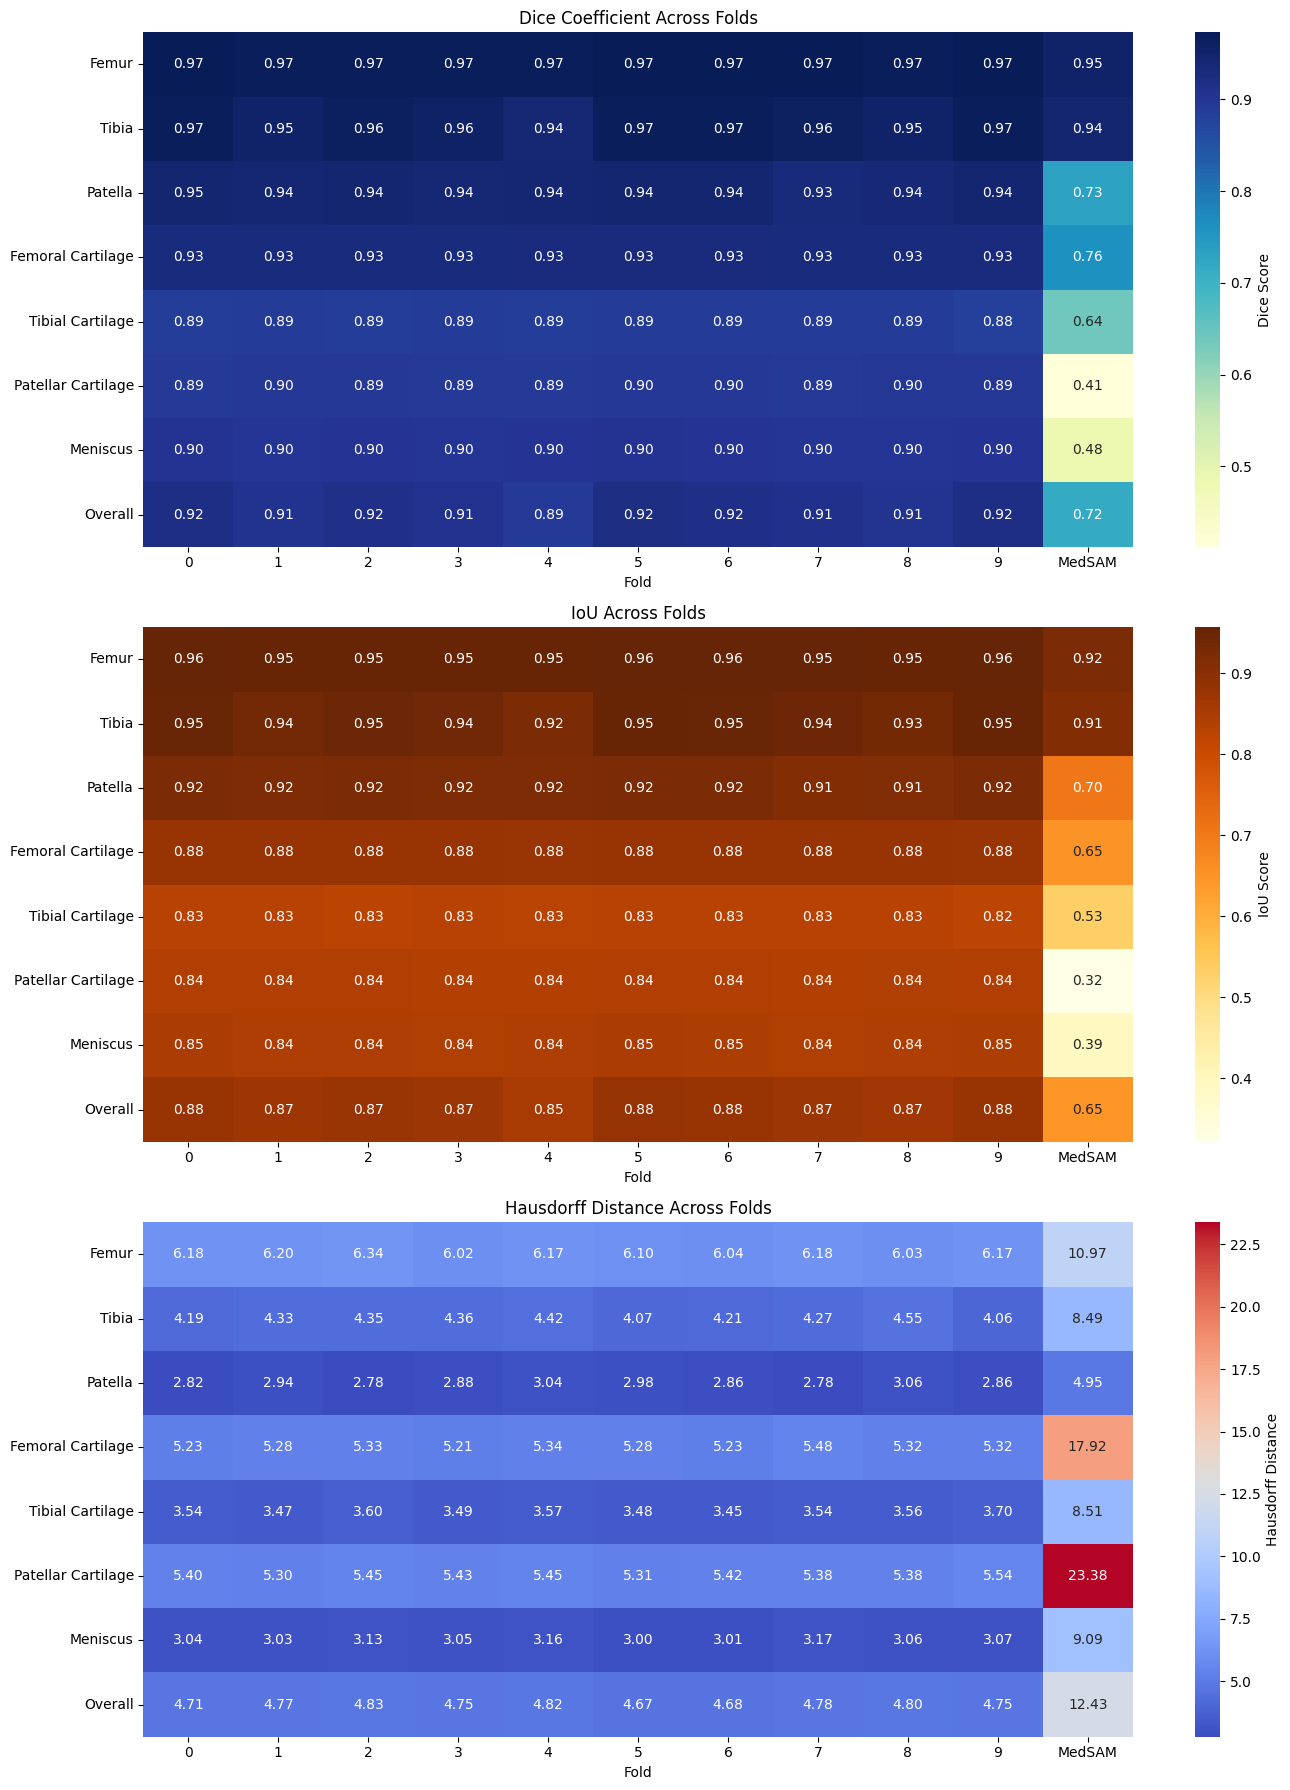

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define structure order
structure_order = [
    "Femur", "Tibia", "Patella", "Femoral Cartilage",
    "Tibial Cartilage", "Patellar Cartilage", "Meniscus", "Overall"
]

# Create pivot tables
dice_data = final_df.pivot(index="case_name", columns="fold", values="mean_dice").loc[structure_order]
iou_data = final_df.pivot(index="case_name", columns="fold", values="mean_iou").loc[structure_order]
hd_data = final_df.pivot(index="case_name", columns="fold", values="mean_hd").loc[structure_order]

# Set up figure with 3 rows
fig, axes = plt.subplots(3, 1, figsize=(14, 18))  # Taller layout

# Dice heatmap
sns.heatmap(dice_data, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Dice Score'})
axes[0].set_title("Dice Coefficient Across Folds")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("")

# IoU heatmap
sns.heatmap(iou_data, annot=True, fmt=".2f", cmap="YlOrBr", ax=axes[1], cbar_kws={'label': 'IoU Score'})
axes[1].set_title("IoU Across Folds")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("")

# Hausdorff Distance heatmap
sns.heatmap(hd_data, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2], cbar_kws={'label': 'Hausdorff Distance'})
axes[2].set_title("Hausdorff Distance Across Folds")
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("")

# Save the figure
plt.tight_layout()
plt.show()
plt.savefig("metrics_heatmaps.pdf", dpi=300)
plt.close()


In [5]:
overall_df = final_df[final_df['case_name'] == 'Overall'].copy()

# Round metric columns to 3 decimal places
overall_df[["mean_dice", "mean_iou", "mean_hd"]] = overall_df[["mean_dice", "mean_iou", "mean_hd"]].round(3)

overall_df


,fold,case_name,mean_dice,mean_iou,mean_hd
7,0,Overall,0.919,0.879,4.708
15,1,Overall,0.908,0.868,4.772
23,2,Overall,0.916,0.875,4.827
31,3,Overall,0.910,0.870,4.749
39,4,Overall,0.894,0.854,4.824
47,5,Overall,0.921,0.880,4.672
55,6,Overall,0.918,0.877,4.683
63,7,Overall,0.912,0.872,4.784
71,8,Overall,0.906,0.866,4.802
79,9,Overall,0.919,0.878,4.750


In [6]:
dfkl=pd.read_csv("/gpfs/home/machlm03/Segmentation/MedSAM2/oai_utils/results/split_dataset_70_10_20_with_cv.csv")
dfkl=dfkl[dfkl['split']=='test']

In [7]:
import pandas as pd
import os

# Directory containing the CSV files
base_dir = "/gpfs/home/machlm03/Segmentation/MedSAM2/oai_utils/results"

# Initialize an empty list to collect DataFrames
dfs = []

# Loop over folds (adjust range as needed)
for i in range(10):  # for fold0.csv to fold9.csv
    file_path = os.path.join(base_dir, f"fold{i}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df = df[["case_name", "mean_dice", "mean_iou", "mean_hd"]]
        df["fold"] = str(i)
        df.reset_index(drop=True, inplace=True)
        dfs.append(df)
    else:
        print(f"File not found: {file_path}")

# Read MedSAM inference results
medsam_df = pd.read_csv(os.path.join(base_dir, "MedSAM2_Inference.csv"))
medsam_df = medsam_df[["case_name", "mean_dice", "mean_iou", "mean_hd"]]
medsam_df["fold"] = "MedSAM"
medsam_df.reset_index(drop=True, inplace=True)

# Combine all into one DataFrame
final_df_combine = pd.concat(dfs + [medsam_df], ignore_index=True)


In [8]:

# Extract ID and laterality to match File_Name
final_df_combine["File_Name"] = final_df_combine["case_name"].str.extract(r"(\d+)_00m_(LEFT|RIGHT)")[0] + "_" + \
                         final_df_combine["case_name"].str.extract(r"(\d+)_00m_(LEFT|RIGHT)")[1]

dfkl=dfkl[['File_Name','V00XRKL']]
merged_df = pd.merge(final_df_combine, dfkl, on="File_Name", how="left")


In [9]:
merged_df.dropna(inplace=True)

In [10]:
merged_df

,case_name,mean_dice,mean_iou,mean_hd,fold,File_Name,V00XRKL
0,9000099_00m_LEFT_SAG_3D_DESS_WE,0.898325,0.849365,6.023477,0,9000099_LEFT,3.0
1,9002411_00m_LEFT_SAG_3D_DESS_WE,0.928583,0.887240,5.290332,0,9002411_LEFT,2.0
2,9002411_00m_RIGHT_SAG_3D_DESS_WE,0.933514,0.894165,4.467788,0,9002411_RIGHT,2.0
3,9003175_00m_LEFT_SAG_3D_DESS_WE,0.866511,0.831079,3.598761,0,9003175_LEFT,0.0
4,9003175_00m_RIGHT_SAG_3D_DESS_WE,0.917723,0.876659,3.979977,0,9003175_RIGHT,0.0
...,...,...,...,...,...,...,...
19094,9997610_00m_RIGHT_SAG_3D_DESS_WE,0.728169,0.663084,12.432000,MedSAM,9997610_RIGHT,2.0
19095,9997856_00m_LEFT_SAG_3D_DESS_WE,0.755428,0.679818,15.101254,MedSAM,9997856_LEFT,4.0
19096,9997856_00m_RIGHT_SAG_3D_DESS_WE,0.752505,0.683334,10.625076,MedSAM,9997856_RIGHT,0.0
19097,9999862_00m_LEFT_SAG_3D_DESS_WE,0.744509,0.668926,12.848295,MedSAM,9999862_LEFT,2.0


In [15]:
# Group by fold and calculate mean and std
summary = (
    merged_df
    .groupby("fold")[["mean_dice", "mean_iou", "mean_hd"]]
    .agg(['mean', 'std'])
    .round(2)
)

# Flatten multi-level columns
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()

# Format as "mean ± std"
summary["Dice"] = summary["mean_dice_mean"].astype(str) + " ± " + summary["mean_dice_std"].astype(str)
summary["IoU"] = summary["mean_iou_mean"].astype(str) + " ± " + summary["mean_iou_std"].astype(str)
summary["HD"] = summary["mean_hd_mean"].astype(str) + " ± " + summary["mean_hd_std"].astype(str)


# Select final formatted columns
formatted_summary = summary[["fold", "Dice", "IoU", "HD"]]


formatted_summary


,fold,Dice,IoU,HD
0,0,0.92 ± 0.03,0.88 ± 0.04,4.71 ± 1.47
1,1,0.91 ± 0.05,0.87 ± 0.05,4.77 ± 1.61
2,2,0.92 ± 0.04,0.87 ± 0.04,4.83 ± 1.51
3,3,0.91 ± 0.05,0.87 ± 0.05,4.75 ± 1.59
4,4,0.89 ± 0.05,0.85 ± 0.05,4.82 ± 1.56
5,5,0.92 ± 0.03,0.88 ± 0.03,4.67 ± 1.45
6,6,0.92 ± 0.03,0.88 ± 0.04,4.68 ± 1.5
7,7,0.91 ± 0.05,0.87 ± 0.05,4.78 ± 1.55
8,8,0.91 ± 0.05,0.87 ± 0.06,4.8 ± 1.69
9,9,0.92 ± 0.03,0.88 ± 0.03,4.75 ± 1.49


In [18]:
# Group by fold and calculate mean and std
# Keep only folds 0–9
filtered_df = merged_df[merged_df["fold"].isin([str(i) for i in range(10)])].copy()

summary = (
    filtered_df
    .groupby("fold")[["mean_dice", "mean_iou", "mean_hd"]]
    .agg(['mean', 'std'])
    .round(2)
)

# Flatten multi-level columns
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()

# Format as "mean ± std"
summary["Dice"] = summary["mean_dice_mean"].astype(str) + " ± " + summary["mean_dice_std"].astype(str)
summary["IoU"] = summary["mean_iou_mean"].astype(str) + " ± " + summary["mean_iou_std"].astype(str)
summary["HD"] = summary["mean_hd_mean"].astype(str) + " ± " + summary["mean_hd_std"].astype(str)

# Select final formatted columns
formatted_summary = summary[["fold", "Dice", "IoU", "HD"]]

# Compute overall mean and std across folds 0–9
overall_mean = filtered_df[["mean_dice", "mean_iou", "mean_hd"]].mean().round(2)
overall_std  = filtered_df[["mean_dice", "mean_iou", "mean_hd"]].std().round(2)

# Format as "mean ± std"
overall_row = {
    "fold": "Overall",
    "Dice": f"{overall_mean['mean_dice']} ± {overall_std['mean_dice']}",
    "IoU":  f"{overall_mean['mean_iou']} ± {overall_std['mean_iou']}",
    "HD":   f"{overall_mean['mean_hd']} ± {overall_std['mean_hd']}"
}

# Append using pd.concat (since .append is deprecated)
import pandas as pd
formatted_summary = pd.concat([formatted_summary, pd.DataFrame([overall_row])], ignore_index=True)

formatted_summary


,fold,Dice,IoU,HD
0,0,0.92 ± 0.03,0.88 ± 0.04,4.71 ± 1.47
1,1,0.91 ± 0.05,0.87 ± 0.05,4.77 ± 1.61
2,2,0.92 ± 0.04,0.87 ± 0.04,4.83 ± 1.51
3,3,0.91 ± 0.05,0.87 ± 0.05,4.75 ± 1.59
4,4,0.89 ± 0.05,0.85 ± 0.05,4.82 ± 1.56
5,5,0.92 ± 0.03,0.88 ± 0.03,4.67 ± 1.45
6,6,0.92 ± 0.03,0.88 ± 0.04,4.68 ± 1.5
7,7,0.91 ± 0.05,0.87 ± 0.05,4.78 ± 1.55
8,8,0.91 ± 0.05,0.87 ± 0.06,4.8 ± 1.69
9,9,0.92 ± 0.03,0.88 ± 0.03,4.75 ± 1.49


In [16]:
# Group by V00XRKL and fold, compute mean and std
summary = (
    merged_df
    .groupby(["V00XRKL", "fold"])[["mean_dice", "mean_iou", "mean_hd"]]
    .agg(['mean', 'std'])
    .round(2)
)

# Flatten multi-level columns
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()

# Format as "mean ± std"
summary["Dice"] = summary["mean_dice_mean"].astype(str) + " ± " + summary["mean_dice_std"].astype(str)
summary["IoU"] = summary["mean_iou_mean"].astype(str) + " ± " + summary["mean_iou_std"].astype(str)
summary["HD"] = summary["mean_hd_mean"].astype(str) + " ± " + summary["mean_hd_std"].astype(str)

# Final formatted table
formatted_summary = summary[["V00XRKL", "fold", "Dice", "IoU", "HD"]]
formatted_summary


,V00XRKL,fold,Dice,IoU,HD
0,0.0,0,0.92 ± 0.03,0.89 ± 0.04,4.32 ± 1.03
1,0.0,1,0.91 ± 0.05,0.88 ± 0.05,4.4 ± 1.27
2,0.0,2,0.92 ± 0.04,0.88 ± 0.04,4.45 ± 1.07
3,0.0,3,0.92 ± 0.05,0.88 ± 0.05,4.38 ± 1.23
4,0.0,4,0.9 ± 0.05,0.86 ± 0.05,4.44 ± 1.13
5,0.0,5,0.93 ± 0.03,0.89 ± 0.03,4.29 ± 1.0
6,0.0,6,0.92 ± 0.03,0.88 ± 0.04,4.3 ± 1.0
7,0.0,7,0.92 ± 0.05,0.88 ± 0.05,4.39 ± 1.08
8,0.0,8,0.91 ± 0.06,0.87 ± 0.06,4.41 ± 1.37
9,0.0,9,0.92 ± 0.03,0.89 ± 0.03,4.36 ± 1.02


In [239]:
filtered = formatted_summary[formatted_summary["fold"].isin(["5", "MedSAM"])].reset_index(drop=True)
filtered


,V00XRKL,fold,Dice,IoU,HD
0,0.0,5,0.93 ± 0.03,0.89 ± 0.03,4.29 ± 1.0
1,0.0,MedSAM,0.73 ± 0.05,0.66 ± 0.05,11.87 ± 2.04
2,1.0,5,0.93 ± 0.02,0.89 ± 0.02,4.29 ± 0.76
3,1.0,MedSAM,0.72 ± 0.05,0.65 ± 0.05,11.79 ± 1.89
4,2.0,5,0.92 ± 0.02,0.88 ± 0.03,4.75 ± 1.05
5,2.0,MedSAM,0.71 ± 0.05,0.64 ± 0.05,12.66 ± 2.55
6,3.0,5,0.91 ± 0.03,0.87 ± 0.03,5.43 ± 1.5
7,3.0,MedSAM,0.7 ± 0.05,0.63 ± 0.05,13.54 ± 2.43
8,4.0,5,0.88 ± 0.07,0.83 ± 0.07,7.52 ± 4.31
9,4.0,MedSAM,0.67 ± 0.07,0.6 ± 0.06,16.12 ± 5.26


/tmp/ipykernel_2274569/528666226.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


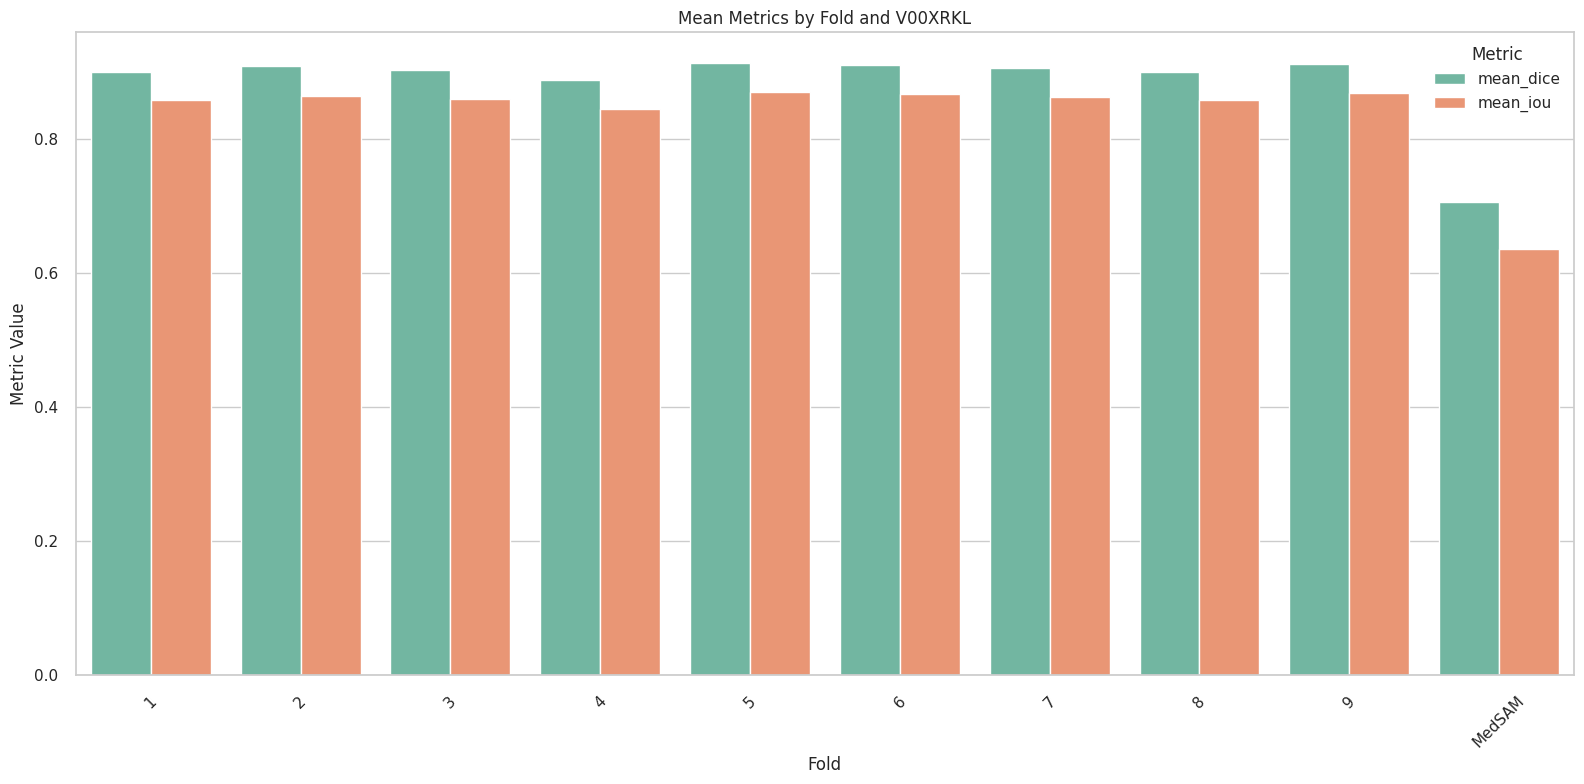

In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting
melted = pd.melt(
    mean_metrics,
    id_vars=["V00XRKL", "fold"],
    value_vars=["mean_dice", "mean_iou"],
    var_name="Metric",
    value_name="Value"
)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=melted,
    x="fold",
    y="Value",
    hue="Metric",
    palette="Set2",
    ci=None
)

# Add facet grid by V00XRKL if needed
# sns.catplot(data=melted, x="fold", y="Value", hue="Metric", col="V00XRKL", kind="bar", col_wrap=3)

# Customize the plot
plt.title("Mean Metrics by Fold and V00XRKL")
plt.xlabel("Fold")
plt.ylabel("Metric Value")
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
